<a href="https://colab.research.google.com/github/soda1102/AI_26/blob/main/07_01_%EC%9D%B8%EA%B3%B5%EC%8B%A0%EA%B2%BD%EB%A7%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# MBC 마켓에서 이번엔 럭키백을 패션분야에 접목 시키려고 한다.

# 패션분야이기 때문에 상품 개수가 늘어나고 어종이 아닌 일반 잡화용으로 제공하기로 했다.

# 딥러닝의 시작, 인공신경망

# MNIST 데이터셋 : 손으로 쓴 0 ~ 9까지의 숫자로 이루어져 있다.
# 패션 MNIST 데이터셋 : 숫자대신 패션아이템으로 이루어진다.

# https://www.kaggle.com/datasets 캐글에가면 연습용 데이터 셋이 많다.
# https://www.aihub.or.kr/ 국내에서 제공하는 연습용 데이터 셋 & 동영상강의

# 텐서플로 연산을 결정적으로 만든다.

# 텐서플로
import tensorflow as tf

# 실행마다 동일한 결과를 얻기 위해 케라스에 랜덤시드를 사용
tf.keras.utils.set_random_seed(42)

# 실험결과를 항상 동일하게 재현하고자 할때(GPU 사용 여부 등에 따른 미세한 결과가 다르다.)
tf.config.experimental.enable_op_determinism()

# 케라스 패키지 임포트
from tensorflow import keras

# load_data()가 훈련세트와 테스트세트로 데이터를 나누어 반환
# input과 target의 쌍으로 이루어진다.

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

In [18]:
# 전달받은 데이터의 크기를 확인
print(train_input.shape, train_target.shape)

# 트레이닝세트(6만개, 28(가로), 28(세로)), (타깃 6만개 1차원 배열)
# 해상도 28 * 28 픽셀

(60000, 28, 28) (60000,)


In [19]:
print(test_input.shape, test_target.shape)
# 테스트 세트(만개, 28가로, 28세로), (타킷 만개 1차원배열)

(10000, 28, 28) (10000,)


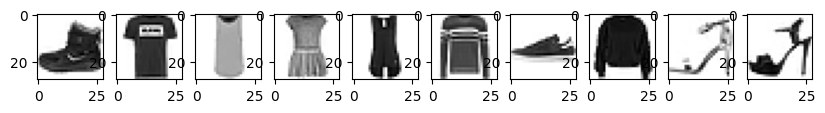

In [20]:
import matplotlib.pyplot as plt

# plt.subplots(1, 20, figsize = (10, 10))
fig, axs = plt.subplots(1, 10, figsize = (10, 10))

# for i in range(20):
for i in range(10):
  axs[i].imshow(train_input[i], cmap = 'gray_r')
  axs[i].axis('on')
plt.show()
# 0티셔츠, 1바지, 2스웨터, 3드레스, 4코트, 5샌달, 6셔츠, 7스니커즈, 8가방, 9앵클부츠

In [21]:
# 샘플타깃 확인
print([train_target[i] for i in range(10)])
# 0 ~ 9까지의 타깃이 있음

[np.uint8(9), np.uint8(0), np.uint8(0), np.uint8(3), np.uint8(0), np.uint8(2), np.uint8(7), np.uint8(2), np.uint8(5), np.uint8(5)]


In [22]:
import numpy as np

# 10개가 배열에 정확히 6000개씩 샘플이 들어있다.
print(np.unique(train_target, return_counts = True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


In [23]:
# 로지스틱 회귀로 패션 아이템 분류하기

# 6만개 전체를 한번에 훈련하는 것보다 샘플 한개씩 꺼내서 모델 훈련을 해보자
# 확률적 경사 하강법 : SGDClassifier(분류용)
# SGDClassifier를 사용할 때 표준화 전처리된 데이터를 사용
# 확률적 경사 하강법은 여러 특성 중 기울기가 가장 가파른 방향을 따라 이동
# 만약 특성마다 값의 범위가 많이 다르면 올바르게 손실함수의 경사를 내려올 수 없다.
# 패션 MNIST의 경우 흑백이기에 0 ~ 255사이의 정수값을 가진다.
#   → 255로 나누어 0 ~ 1사이값으로 정규화 진행(양수값으로 이루어진 이미지 전처리용)

# reshape로 2차원 배열을 1차원 배열로 펼친다.
train_scaled = train_input / 255.0

# -1은 모든 값
train_scaled = train_scaled.reshape(-1, 28 * 28)

print(train_scaled.shape)
# SGDClassifier은 2차원 지원X (28 * 28 = 784) (특성)

(60000, 784)


In [24]:
# 크로스 검증
from sklearn.model_selection import cross_validate

# 경사하강법
from sklearn.linear_model import SGDClassifier

# max_iter : 5번 반복(에포크), cross_validate : 교차검증
sc = SGDClassifier(loss = 'log_loss', max_iter = 5, random_state = 42)
scores = cross_validate(sc, train_scaled, train_target, n_jobs = -1)

print(np.mean(scores['test_score']))

# 5번 반복에 대한 테스트 평균, 35초 정도 소요

0.8194166666666666


In [25]:
# 로지스틱 회귀(과거에 학습한 내용)
# z = a * (Weight) + b * (Length) + c * (Diagonal) + d * (Height) + e * (Width) + f

# 선형방정식
# z_티셔츠 = a * (픽셀1) + b * (픽셀2) + c * (픽셀3) + d * (픽셀4) ... + e * (픽셀784) + f(절편)

# 바지에 대한 출력은 티셔츠와 다른 값을 사용해야 한다.(티셔츠와 다르다.)
# z_바지 = a1 * (픽셀1) + b1 * (픽셀2) + c1 * (픽셀3) + d1 * (픽셀4) ... + e1 * (픽셀784) + f1(절편)

# 나머지 클래스에 대한 선형 방정식도 동일
#   → 10개의 클래스에 대한 선형방정식을 모두 계산.
# 다음단계인 소프트맥스 함수(다중분류)를 통과하여 각 클래스에 대한 확률을 얻을 수 있다.
# 0티셔츠, 1바지, 2스웨터, 3드레스, 4코트, 5샌달, 6셔츠, 7스니커즈, 8가방, 9앵클부츠

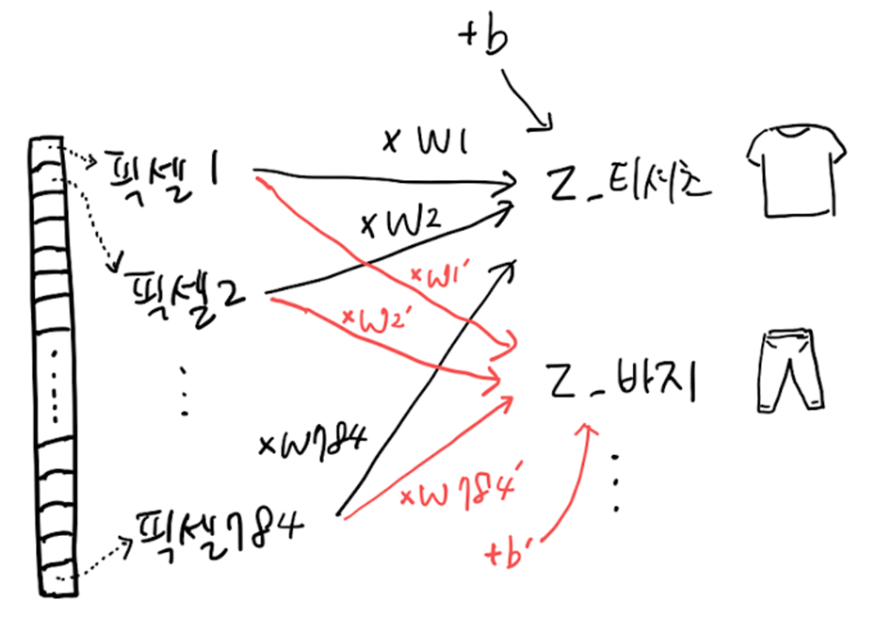

In [26]:
# 인공신경망(srtificial 아티피셜 / neural 뉴럴 / network, ANN)을 사용하여 패션 아이템 분류 문제의 성능을 높혀보자.

# z_티셔츠 ~ z_앵클부츠 클래스 10개인 z_10 까지 계산하고 이를 바탕으로 클래스를 예측하기 때문에
# 신경망의 최종 값은 출력층(output Layer)

# 인공신경망의 z 값 계산하는 단위는 뉴런(Neuron)이라고 부른다.
# → 선형계산을 진행 (대부분 유닛이라고 부른다.)

# 픽셀1 ~ 784번 픽셀까지를 입력층(input layer)이라고 부름 → train_scaled

# z_1를 만들기 위해서 픽셀1인 x_1 에 곱해지는 가중치는 w_1.1 ..... 10개의 뉴런
# 사람 뇌에 있는 뉴런과 다르다. (무언가를 만들어내는 것이 아니라 알고리즘의 일종)
# 확률적 경사 하강법을 사용한 로지스틱 회귀 모델이
# 가장 간단한 인공 신경망이라면 인공 신경망을 만들어도 성능이 좋아지지 않는다.
# 이미 인공신경망을 만들었다.
# 확률적 경사 하강법을 사용한 로지스틱 회귀는 가장 간단한 인공 신경망 모델이다.

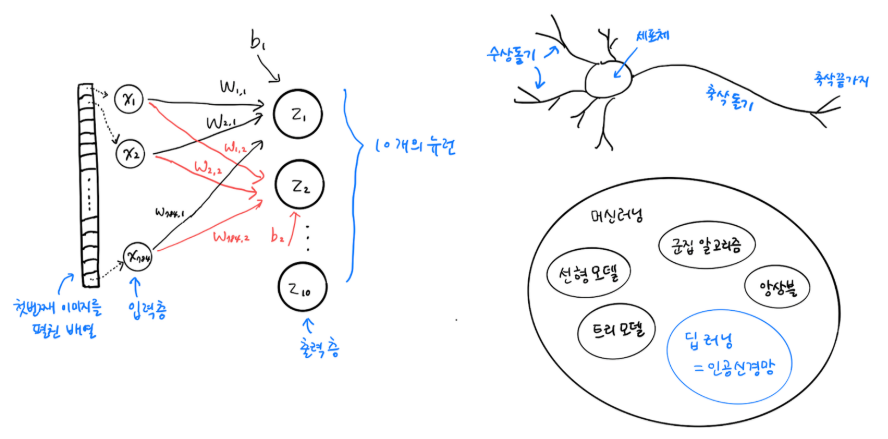

In [27]:
# 딥러닝 라이브러리에서 인기 높은 텐서플로를 사용해보자

# 텐서플로(TensorFlow)
# 구글이 2015년 11월 오픈소스로 공개한 딥러닝 라이브러리이다. → 알파고 시절(이세돌)
# 텐서플로우 2.x 버전이 2019년 9월에 릴리스 되었다.

import tensorflow as tf

# 케라스 : 고수준 api
from tensorflow import keras

# 딥러닝 라이브러리는 GPU(그래픽카드)를 사용하여 인공 신경망을 훈련
# GPU는 벡터와 행렬 연산으로 3D 연산에 최적화 되어있다.
# 곱셈과 덧셈이 많이 수행되는 인공 신경망에 속도를 높여준다.
# 케라스 라이브러리는 직접 GPU 연산을 수행하지 않는다.

# https://www.youtube.com/watch?v=AKob3yZT0I4

# 대신 GPU 연산을 수행하는 다른 라이브러리를 백엔드로 사용
# 텐서플로가 케라스 백엔드로 사용할 수 있다.
#   → 멀티 - 백엔드 케라스라고 부른다.
# 케라스가 API만 익히면 다양한 딥러닝 라이브러리를 입맛대로 골라서 사용할 수 있다.
#   → 직관적이고 사용하기 편하다.

In [28]:
# 인공신경망으로 모델 만들기
#  : 앞에서 만든 train_scaled, train_target을 사용
# 인공신경망에서는 교차 검증을 사용하지 않고 검증세트를 별도로 덜어내어 사용
# 이유 1 : 딥러닝 분야의 데이터셋은 충분히 크기 때문에 검증 점수가 안정적
# 이유 2 : 교차 검증을 수행하기에는 훈련시간이 너무 오래걸린다.
#   → fit 시간이 몇시간, 며칠이 걸릴 수도 있다.

from sklearn.model_selection import train_test_split
# train_scaled(트레이닝 스케일), val_scaled(값 스케일 = 검증세트 20%)
# train_target(트레이닝 타겟), val_target(값 타겟 = 검증세트 20%)

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

# 훈련세트 48,000 +
print(train_scaled.shape, train_target.shape)

# 검증세트 12,000 = 60,000
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


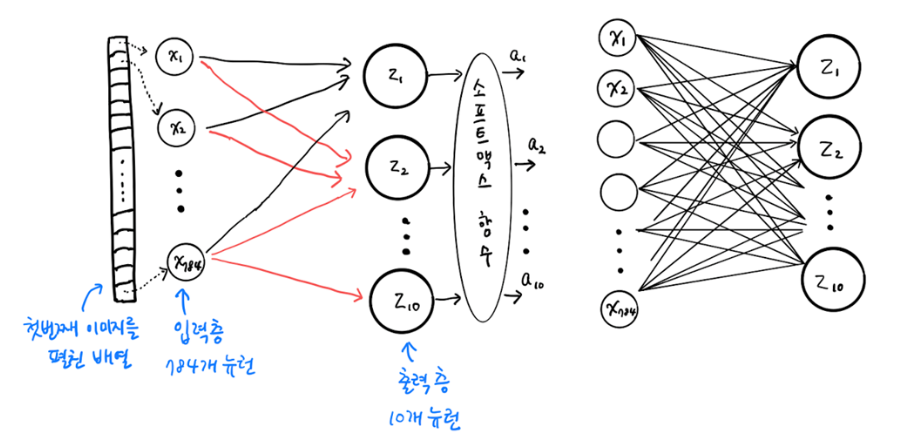

In [28]:
# 딥러닝에서는 다양한 종류의 층을 추가하는 식으로 모델을 만든다.
# 이번 장에서는 Dense 층을 사용. 밀집층, 완전 연결층 fully connteced layer

# 10개의 유닛 → 타겟이 10개
# 다중 분류 : 활성화 함수는 소프트맥스
# 입력값은 784개의 원소로 이루어진 1차원 배열(픽셀 28*28)
# 이진 분류 : 시그모이드 함수 사용

# 케라스는 첫번째 층에 입력 크기를 넣어야 한다.
# 그 다음에 추가되는 층은 자동으로 계산되기 때문에 넣을 필요가 없다.
# 케라스 모델은 Sequential(순차적) 클래스로 만든다.

# 인공 신경망의 오른쪽에 놓인 층을 만든다.
# 10개의 패션 아이템을 분류하기 위해 10개의 뉴런으로 구성

# 케라스의 레이어 패키지 안에는 다양한 층이 존재,
# 가장 기본이 되는 층이 밀집층(dense layer)
# 밀집층(danse layer) : 784개의 픽셀과 10개의 뉴런이 모두 연결된 선이라는 뜻
# 총 784 * 10 = 7840개의 연결선이 있다.

# 이런 층을 뉴런이 모두 연결하고 있어 완전 연결층(fully connected layer)라고 부른다.

In [29]:
# 딥러닝에서 사용할 레이어를 만든다.
dense = keras.layers.Dense(10, activation = 'softmax', input_shape = (784,))
# 10 : 뉴런 개수 / activation = 'softmax' : 뉴런에 적용할 함수 / input_shape : 입력의 크기

# activation = 'softmax' : 출력되는 값을 확률로 바꾼다. → 다중분류
# activation = 'sigmoid' : 2진 분류
# 입력의 크기는 10개의 뉴런이 각각 몇개의 입력을 받는지 튜플로 지정.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
# 이제 밀집층을 가진 신경망 모델을 만들자. → 각각층을 구현할 객체

model = keras.Sequential([dense])

# 밀집층을 가진 신경망 모델을 만든다.
# Sequential(순차적 구조) 클래스를 사용
# Sequential 클래스의 객체를 만들 때 앞에서 만든 밀집층의 객체 dense를 전달
# 여기서 만든 model 객체가 바로 신경망 모델.

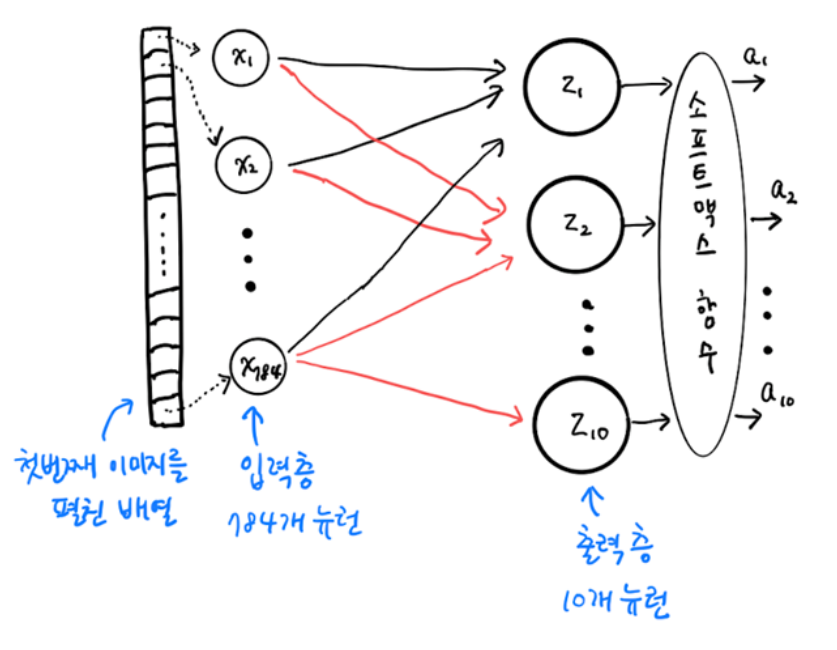

In [33]:
# 활성화(activation) 함수 : 소프트맥스와 같이 뉴런의 선형 방정식 계산 결과에 적용되는 함수
# 위 그림을 보면 a 표시 되어있다.

# 인공신경망으로 패션 아이템 분류하기 전처리 완료

# 케라스 모델 훈련전, 설정단계 끝!


# model 객체의 compile() 메서드에서 수행
# 손실함수 loss = 'sparse_categorical_crossentropy' (히소 다중분류 손실함수) → 정수타깃
#                         binary_crossentropy (히소 2진분류 손실함수) → 이진타깃

# 측정값 metrics = ['accuracy'] → 정확도(에큐러시)의 지표가 된다.

model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# 케라스는 자동으로 에포크마다 손실을 기록.
# 추가로 정확도를 기록하기 위해 metrics

# 0티셔츠, 1바지, 2스웨터, 3드레스, 4코트, 5샌달, 6셔츠, 7스니커즈, 8가방, 9앵클부츠

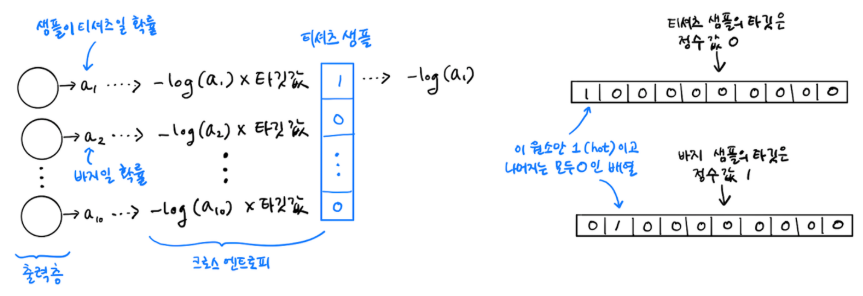

In [35]:
# 정수형으로 타깃 생성되어 있다. → 원-핫 인코딩
print(train_target[:10])

# 정답에 인덱스가 나옴
# 0티셔츠, 1바지, 2스웨터, 3드레스, 4코트, 5샌달, 6셔츠, 7스니커즈, 8가방, 9앵클부츠

# 모델 컴파일 종료 끝!

[7 3 5 8 6 9 3 3 9 9]


In [39]:
# 훈련시작(에포크 5로 5번 훈련중, 26초 소요)
model.fit(train_scaled, train_target, epochs = 5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8552 - loss: 0.4277
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8570 - loss: 0.4232
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8579 - loss: 0.4197
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8592 - loss: 0.4169
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8597 - loss: 0.4145


In [37]:
# 에포크마다 걸린시간, 정확도(accuracy), 손실(loss)
# 0.8537 높은 점수를 받았다.

# 케라스 모델의 성능 평가하는 메서드 evaluate(이밸류에이트)
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8462 - loss: 0.4364


[0.4444445073604584, 0.8458333611488342]

In [38]:
# 사이킷런과 케라스 모델 비교

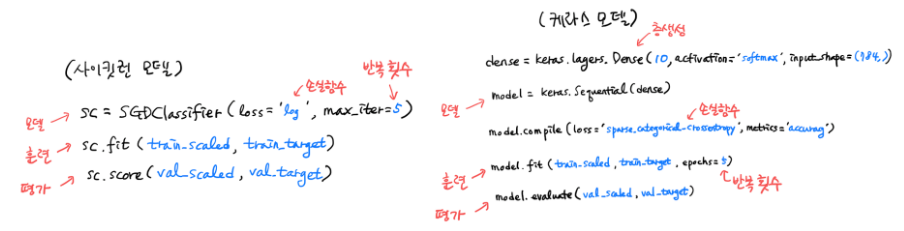